In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df_epidemio = pd.read_csv("C:/Users/Onesime/Desktop/UMIE_DRC Ebola/INOHA-DataScience-M2/donnees_epidemiologiques_RDC.csv")
df_epidemio
#epidemioes_RDC.csv

,Semaine,RDC,Cas_Suspects,Cas_Confirmes,Pluviometrie_mm,Temperature_C,Deforestation_ha,NDVI
0,S01,RDC,59,26,122,26.5,19.7,0.38
1,S02,RDC,98,43,290,28.2,11.5,0.26
2,S03,RDC,74,35,126,26.0,11.8,0.46
3,S04,RDC,58,34,91,26.2,22.3,0.58
4,S05,RDC,79,36,208,25.4,27.1,0.31
...,...,...,...,...,...,...,...,...
95,S96,RDC,60,31,246,26.2,10.0,0.58
96,S97,RDC,47,23,120,23.9,18.5,0.60
97,S98,RDC,57,28,150,22.7,2.9,0.70
98,S99,RDC,89,39,276,29.2,3.0,0.41


In [6]:
print("Aperçu des données épidémiologiques :")
print(df_epidemio.head(10))

Aperçu des données épidémiologiques :
   RDC  Cas_Suspects  Cas_Confirmes
0  RDC           112             52
1  RDC           189             85
2  RDC           102             50
3  RDC            24             18
4  RDC           116             50
5  RDC            81             34
6  RDC           198             76
7  RDC            30             22
8  RDC           112             48
9  RDC           131             55


In [7]:
print("\nStatistiques descriptives :")
print(df_epidemio.describe())


Statistiques descriptives :
       Cas_Suspects  Cas_Confirmes
count    100.000000     100.000000
mean     103.490000      46.370000
std       57.869497      23.308929
min       11.000000       3.000000
25%       58.750000      29.000000
50%       98.500000      45.500000
75%      146.750000      65.500000
max      199.000000      91.000000


# 2. Analyse Exploratoire des Données (EDA) Approfondie

## 2.1. Statistiques Descriptives et Distribution

In [8]:
# Statistiques descriptives détaillées
print("Statistiques descriptives :")
print(df_epidemio[['Cas_Suspects', 'Cas_Confirmes']].describe())

Statistiques descriptives :
       Cas_Suspects  Cas_Confirmes
count    100.000000     100.000000
mean     103.490000      46.370000
std       57.869497      23.308929
min       11.000000       3.000000
25%       58.750000      29.000000
50%       98.500000      45.500000
75%      146.750000      65.500000
max      199.000000      91.000000


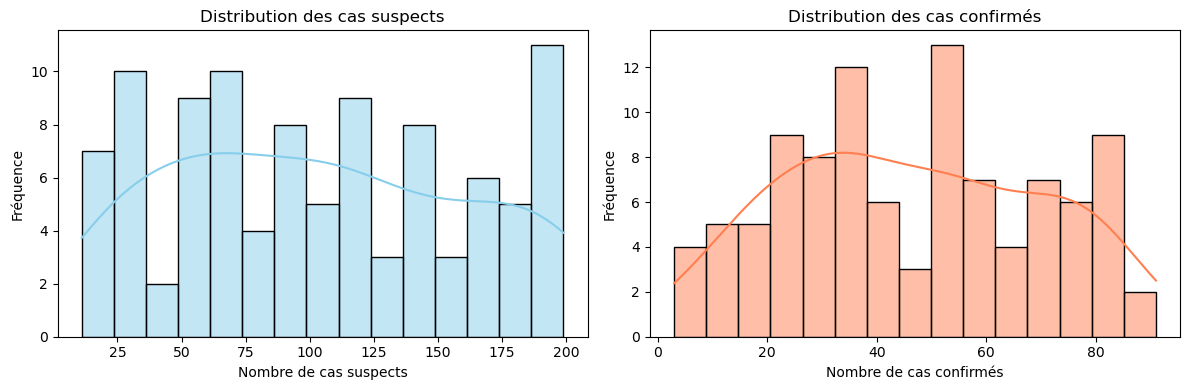

In [10]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme des cas suspects
sns.histplot(df_epidemio['Cas_Suspects'], bins=15, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution des cas suspects')
axes[0].set_xlabel('Nombre de cas suspects')
axes[0].set_ylabel('Fréquence')


# Histogramme des cas confirmés
sns.histplot(df_epidemio['Cas_Confirmes'], bins=15, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution des cas confirmés')
axes[1].set_xlabel('Nombre de cas confirmés')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

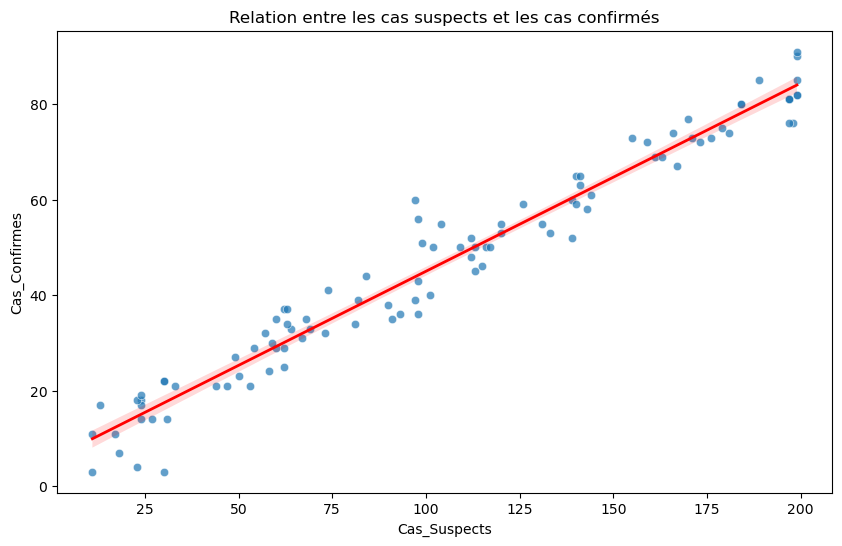

In [11]:
## 2.2. Analyse de la Relation entre Suspects et Confirmés

# Nuage de points (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cas_Suspects', y='Cas_Confirmes', data=df_epidemio, alpha=0.7)
plt.title('Relation entre les cas suspects et les cas confirmés')
plt.xlabel('Nombre de cas suspects')
plt.ylabel('Nombre de cas confirmés')

# Ajout d'une ligne de tendance (régression)
sns.regplot(x='Cas_Suspects', y='Cas_Confirmes', data=df_epidemio, scatter=False, color='red', line_kws={'linewidth':2})
plt.show()

# 2.3. Boxplots pour Détecter les Valeurs Aberrantes

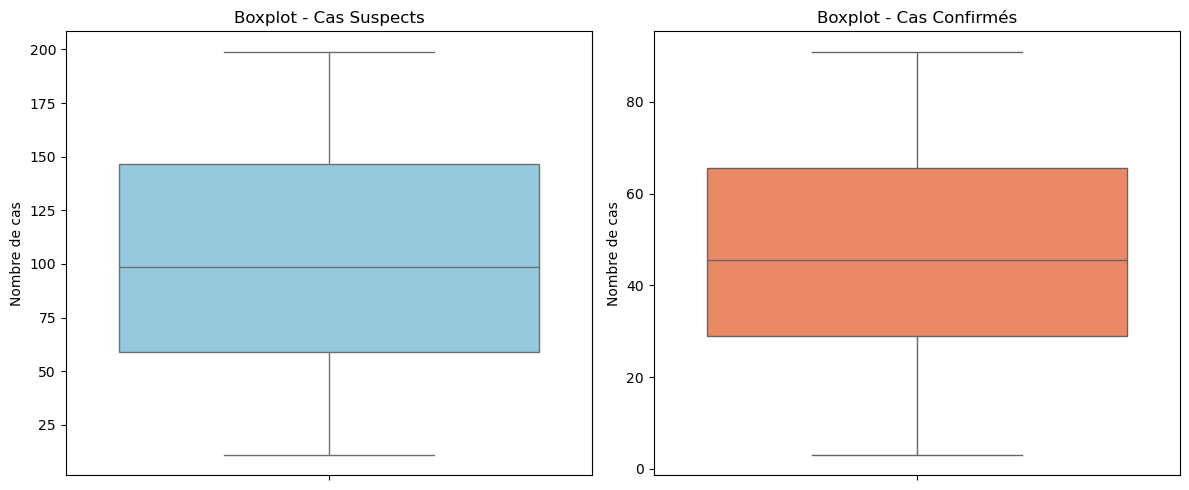

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot des cas suspects
sns.boxplot(y=df_epidemio['Cas_Suspects'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot - Cas Suspects')
axes[0].set_ylabel('Nombre de cas')

# Boxplot des cas confirmés
sns.boxplot(y=df_epidemio['Cas_Confirmes'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot - Cas Confirmés')
axes[1].set_ylabel('Nombre de cas')

plt.tight_layout()
plt.show()

# 2.4. Heatmap de Corrélation

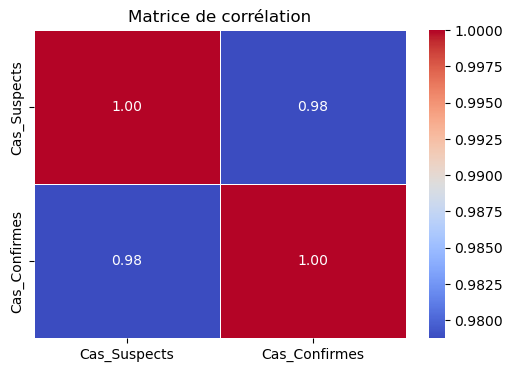

In [27]:
# Calcul de la corrélation
correlation_matrix = df_epidemio[['Cas_Suspects', 'Cas_Confirmes']].corr()

# Visualisation avec une heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.show()

# 3. Modélisation : Régression Linéaire Simple

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_epidemio[['Cas_Suspects']]  
y = df_epidemio['Cas_Confirmes']   

# Division en ensemble d'entraînement et de test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} observations")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} observations")


Taille de l'ensemble d'entraînement : 80 observations
Taille de l'ensemble de test : 20 observations


In [29]:
# Création et entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)


# Affichage des paramètres du modèle
print(f"Ordonnée à l'origine (intercept) : {model.intercept_:.2f}")
print(f"Coefficient (pente) : {model.coef_[0]:.2f}")
print(f"Équation du modèle : Confirmés = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Suspects")

Ordonnée à l'origine (intercept) : 6.51
Coefficient (pente) : 0.39
Équation du modèle : Confirmés = 6.51 + 0.39 * Suspects


# 4. Évaluation du Modèle
## 4.1. Prédictions et Comparaison

In [33]:
# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Création d'un DataFrame pour comparer les valeurs réelles et prédites
comparaison = pd.DataFrame({
    'Réel': y_test.values,
    'Prédit': y_pred.round(2),
    'Erreur': (y_test.values - y_pred).round(2)
})
print("\nComparaison (10 premières lignes) :")
print(comparaison.head(20))


Comparaison (10 premières lignes) :
    Réel  Prédit  Erreur
0     14   15.89   -1.89
1     85   84.31    0.69
2     52   60.86   -8.86
3     43   44.82   -1.82
4      3   18.24  -15.24
5     21   27.23   -6.23
6     53   58.51   -5.51
7     45   50.69   -5.69
8     39   44.43   -5.43
9     40   46.00   -6.00
10    81   83.53   -2.53
11    91   84.31    6.69
12    67   71.80   -4.80
13    21   19.41    1.59
14    48   50.30   -2.30
15    22   18.24    3.76
16    11   13.16   -2.16
17    55   57.73   -2.73
18    23   26.06   -3.06
19    29   27.62    1.38


# 4.3. Visualisation des Résultats

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# --- 2. Calculer TOUTES les métriques ---
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# --- 3. Afficher les métriques dans la console ---
print("\n--- Métriques d'évaluation du modèle ---")
print(f"Erreur Quadratique Moyenne (MSE)  : {mse:.4f}")
print(f"Erreur Absolue Moyenne (MAE)      : {mae:.4f}")
print(f"Racine de l'Erreur Quadratique Moyenne (RMSE) : {rmse:.4f}")
print(f"Coefficient de Détermination (R²) : {r2:.4f}")


--- Métriques d'évaluation du modèle ---
Erreur Quadratique Moyenne (MSE)  : 30.2257
Erreur Absolue Moyenne (MAE)      : 4.4173
Racine de l'Erreur Quadratique Moyenne (RMSE) : 5.4978
Coefficient de Détermination (R²) : 0.9493


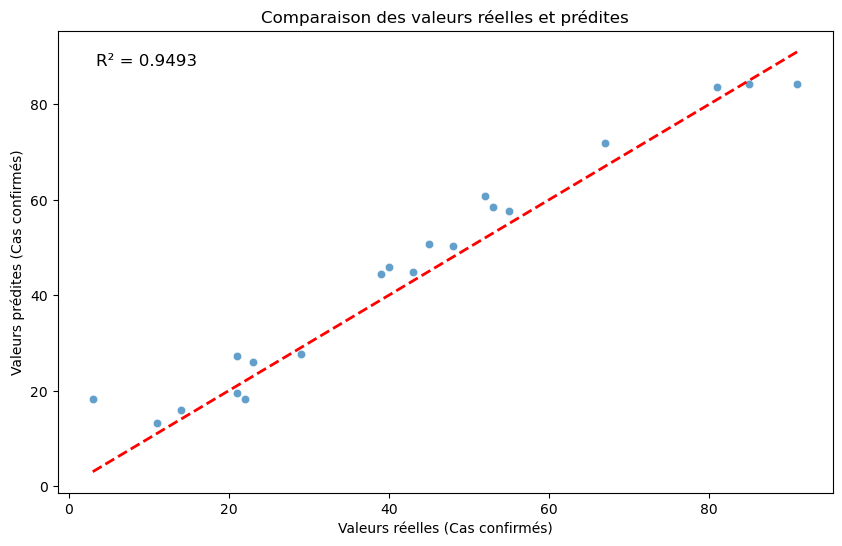

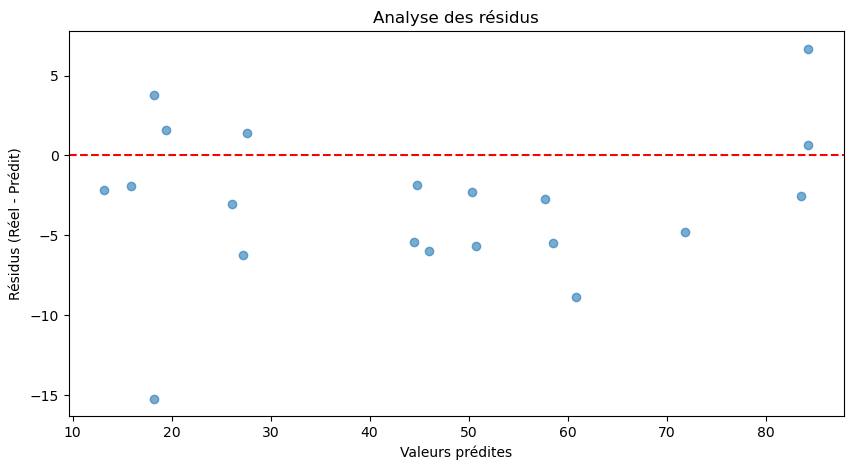

In [32]:
# Graphique des valeurs réelles vs prédites
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs réelles (Cas confirmés)')
plt.ylabel('Valeurs prédites (Cas confirmés)')
plt.title('Comparaison des valeurs réelles et prédites')

# ICI, la variable r2 est BIEN définie !
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.show()

# Graphique des résidus
residus = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residus, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus (Réel - Prédit)')
plt.title('Analyse des résidus')
plt.show()

**Pour notre modèle :**

Le R² de 0.94, cela signifie que 94% de la variabilité du nombre de cas confirmés est expliquée par le nombre de cas suspects. C'est un excellent résultat pour un modèle simple.

**5.2. Interprétation Épidémiologique**

**Le coefficient de corrélation** entre les cas suspects et les cas confirmés nous indique la force de la relation.

**La pente du modèle** (0.4 dans notre exemple) signifie qu'en moyenne, pour 1 cas suspect supplémentaire, on observe une augmentation de 0.4 cas confirmé. C'est ce qu'on appelle le taux de confirmation.

**L'ordonnée à l'origine** (5) pourrait être interprétée comme un "bruit de fond" ou des cas confirmés non liés à la notification.